In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### The Problem

Identify which factors predict future user adoption.

"adopted user" is a user who has logged into the product on three seperate days in at least one seven-day period

In [2]:
df_engagement = pd.read_csv("../takehome_user_engagement.csv")
df_engagement.head()

,time_stamp,user_id,visited
0,2014-04-22 03:53:30,1,1
1,2013-11-15 03:45:04,2,1
2,2013-11-29 03:45:04,2,1
3,2013-12-09 03:45:04,2,1
4,2013-12-25 03:45:04,2,1


In [3]:
# find which users are adopted users
df_engagement['time_stamp'] = pd.to_datetime(df_engagement['time_stamp'])
df_engagement['date'] = df_engagement['time_stamp'].dt.date

df_engagement.head()
adopted_users = set()
for user_id, user_data in df_engagement.groupby('user_id'):
    user_data = user_data.sort_values('time_stamp')
    user_data = user_data.drop_duplicates(subset=['date'])
    user_data = user_data.reset_index(drop=True)
    for i in range(len(user_data) - 2):
        if (user_data.loc[i + 2, 'time_stamp'] - user_data.loc[i, 'time_stamp']).days <= 7:
            adopted_users.add(user_id)
            break

In [4]:
# our adopted users
print(len(adopted_users))
print(adopted_users)

1656
{8192, 2, 8196, 8201, 10, 20, 8214, 8217, 8220, 8221, 33, 8232, 8233, 42, 43, 8235, 8239, 50, 8243, 53, 60, 8252, 63, 8255, 8258, 8259, 69, 8265, 74, 8270, 80, 81, 82, 8277, 8278, 87, 8280, 8294, 8297, 8310, 8311, 8319, 133, 135, 141, 8334, 146, 153, 8348, 160, 165, 168, 172, 174, 8366, 8371, 185, 188, 8381, 8383, 197, 200, 8393, 202, 203, 8394, 8399, 209, 8401, 8403, 214, 8408, 8415, 230, 8426, 8435, 245, 247, 8440, 8442, 8448, 263, 265, 8460, 8463, 8466, 275, 280, 283, 297, 298, 8493, 305, 310, 311, 8505, 8507, 8508, 8511, 321, 322, 8523, 341, 345, 8538, 347, 351, 8553, 362, 363, 370, 8569, 8571, 383, 8581, 397, 401, 8593, 8595, 8601, 8602, 418, 8615, 430, 8622, 445, 8639, 8640, 450, 460, 462, 8654, 469, 471, 472, 478, 479, 8673, 483, 8675, 8677, 8679, 492, 494, 497, 8689, 502, 8695, 506, 509, 510, 8701, 512, 8704, 8706, 8708, 518, 520, 8712, 522, 529, 8721, 8725, 535, 540, 547, 8740, 8741, 553, 8749, 8750, 564, 8760, 572, 8767, 8768, 8769, 8770, 8779, 589, 591, 8789, 8790, 601,

In [47]:
df_users = pd.read_csv('../takehome_users.csv', encoding = "latin1")
df_users.head()

,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1.398139e+09,1,0,11,10803.0
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1.396238e+09,0,0,1,316.0
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1.363735e+09,0,0,94,1525.0
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1.369210e+09,0,0,1,5151.0
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1.358850e+09,0,0,193,5240.0


In [48]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   object_id                   12000 non-null  int64  
 1   creation_time               12000 non-null  object 
 2   name                        12000 non-null  object 
 3   email                       12000 non-null  object 
 4   creation_source             12000 non-null  object 
 5   last_session_creation_time  8823 non-null   float64
 6   opted_in_to_mailing_list    12000 non-null  int64  
 7   enabled_for_marketing_drip  12000 non-null  int64  
 8   org_id                      12000 non-null  int64  
 9   invited_by_user_id          6417 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 937.6+ KB


In [49]:
df_users['creation_time'] = pd.to_datetime(df_users['creation_time'])
df_users['name'] = df_users['name'].astype('string')
df_users['email'] = df_users['email'].astype('string')
df_users['last_session_creation_time'] = pd.to_datetime(df_users['last_session_creation_time'])
df_users['creation_source'] = df_users['creation_source'].astype('string')
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   object_id                   12000 non-null  int64         
 1   creation_time               12000 non-null  datetime64[ns]
 2   name                        12000 non-null  string        
 3   email                       12000 non-null  string        
 4   creation_source             12000 non-null  string        
 5   last_session_creation_time  8823 non-null   datetime64[ns]
 6   opted_in_to_mailing_list    12000 non-null  int64         
 7   enabled_for_marketing_drip  12000 non-null  int64         
 8   org_id                      12000 non-null  int64         
 9   invited_by_user_id          6417 non-null   float64       
dtypes: datetime64[ns](2), float64(1), int64(4), string(3)
memory usage: 937.6 KB


In [50]:
#change invited_by_user_id null values to 0 because there is no user with id 0
# last_session_creation_time has null values, but we will leave them as is for now

df_users['invited_by_user_id'] = df_users['invited_by_user_id'].fillna('0')
df_users.isnull().sum()

object_id                        0
creation_time                    0
name                             0
email                            0
creation_source                  0
last_session_creation_time    3177
opted_in_to_mailing_list         0
enabled_for_marketing_drip       0
org_id                           0
invited_by_user_id               0
dtype: int64

In [51]:
# now we will add a column to df_users to indicate if the user is an adopted user
df_users['is_adopted'] = df_users['object_id'].apply(lambda x: 1 if x in adopted_users else 0)  

In [52]:
df_users.head()


,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,is_adopted
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1970-01-01 00:00:01.398138810,1,0,11,10803.0,0
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1970-01-01 00:00:01.396237504,0,0,1,316.0,1
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1970-01-01 00:00:01.363734892,0,0,94,1525.0,0
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1970-01-01 00:00:01.369210168,0,0,1,5151.0,0
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1970-01-01 00:00:01.358849660,0,0,193,5240.0,0


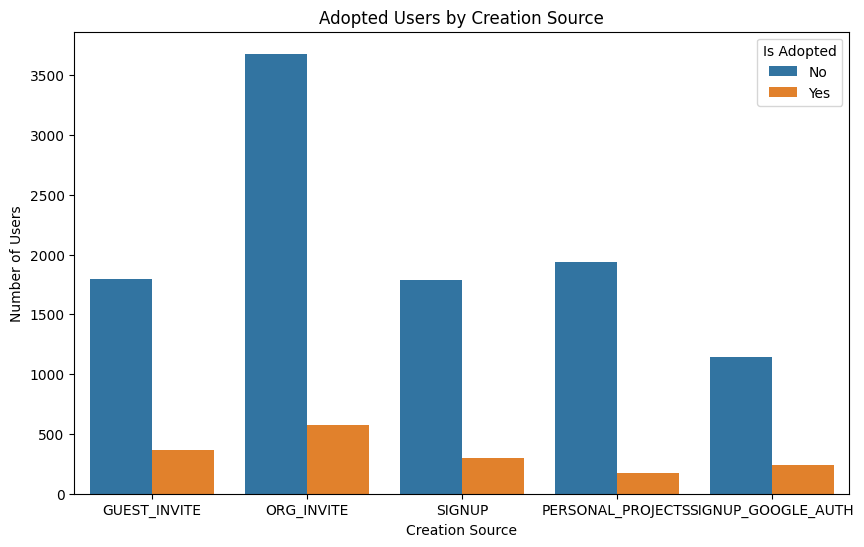

In [55]:
# make a graph of adopted users grouped by creation source
plt.figure(figsize=(10, 6))
sns.countplot(data=df_users, x='creation_source', hue='is_adopted')
plt.title('Adopted Users by Creation Source')
plt.xlabel('Creation Source')
plt.ylabel('Number of Users')
plt.legend(title='Is Adopted', labels=['No', 'Yes'])
plt.show()

Creation source doesn't show much corrilation with adopted users, but compared to total users, there is an average adopted user retention for each catagory I feel.

In [56]:
# one hot encode lables for creation_source, org_id, and invited_by_user_id
df_users = pd.get_dummies(df_users, columns=['creation_source'], drop_first=False)

# drop name and email columns
df_users = df_users.drop(columns=['name', 'email'])

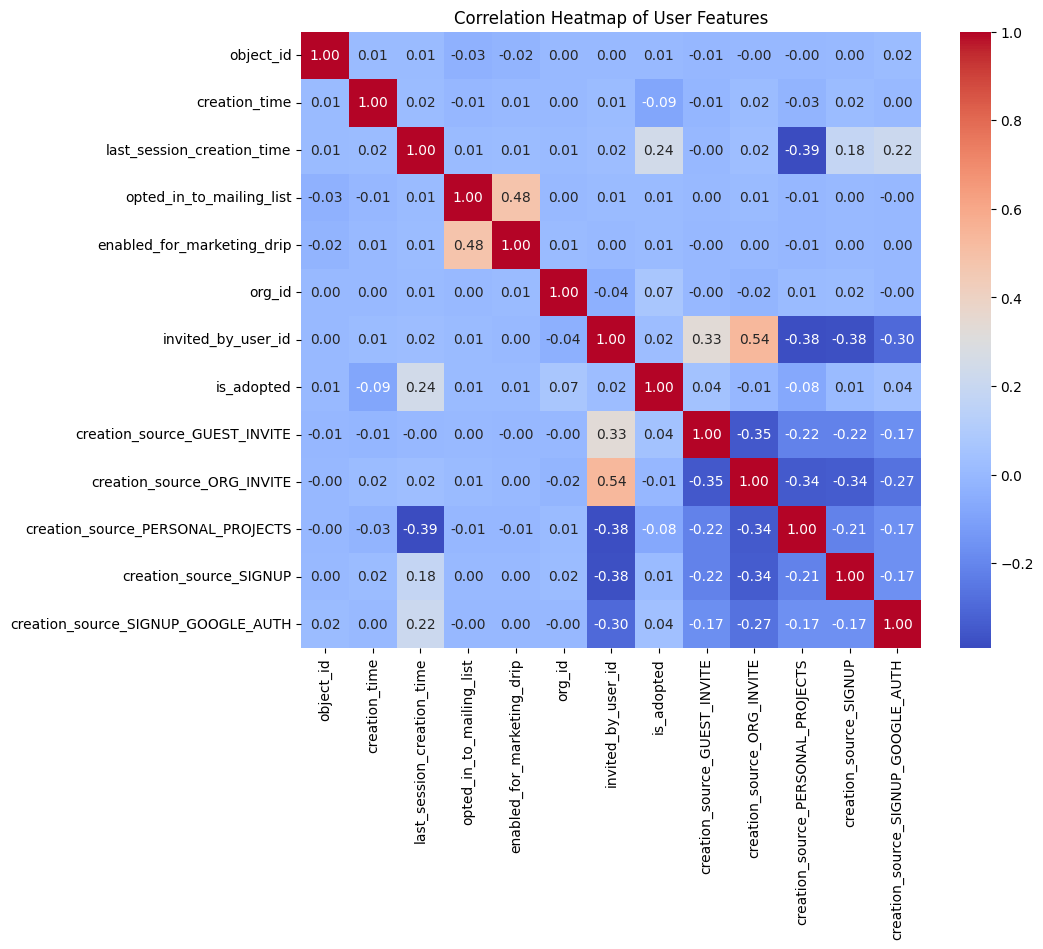

In [57]:
# create a heatmap to show correlation between features
plt.figure(figsize=(10, 8))
sns.heatmap(df_users.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of User Features')
plt.show()

The highest corrilations for an adopted users is creation time, Last session (because they are still active), org_id, invited_by_user_id, and creation_source.

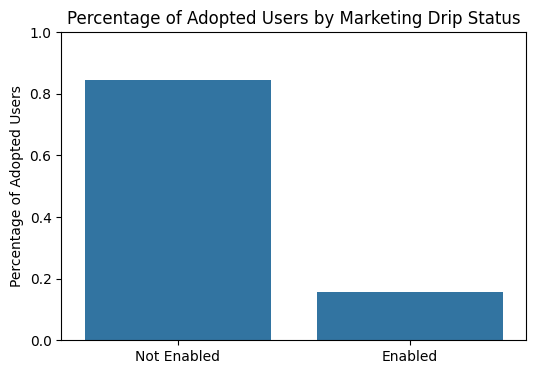

In [58]:
# make a graph of the percentage of adopted users that are enabled for marketing drip
plt.figure(figsize=(6, 4))
sns.barplot(x=['Not Enabled', 'Enabled'], y=[df_users[(df_users['enabled_for_marketing_drip'] == False) & (df_users['is_adopted'] == 1)].shape[0] / df_users[df_users['is_adopted'] == 1].shape[0], df_users[(df_users['enabled_for_marketing_drip'] == True) & (df_users['is_adopted'] == 1)].shape[0] / df_users[df_users['is_adopted'] == 1].shape[0]])
plt.ylabel('Percentage of Adopted Users')
plt.title('Percentage of Adopted Users by Marketing Drip Status')
plt.ylim(0, 1)
plt.show()

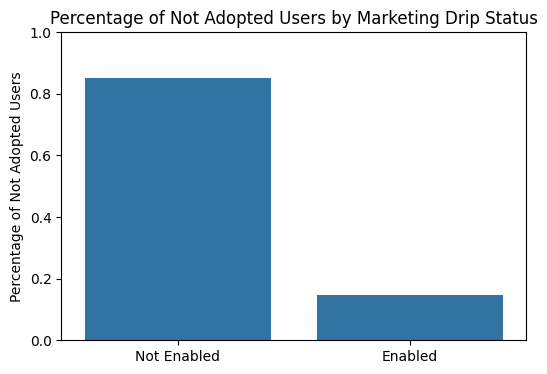

In [59]:
# make a graph of the percentage of adopted users that are enabled for marketing drip
plt.figure(figsize=(6, 4))
sns.barplot(x=['Not Enabled', 'Enabled'], y=[df_users[(df_users['enabled_for_marketing_drip'] == False) & (df_users['is_adopted'] == 0)].shape[0] / df_users[df_users['is_adopted'] == 0].shape[0], df_users[(df_users['enabled_for_marketing_drip'] == True) & (df_users['is_adopted'] == 0)].shape[0] / df_users[df_users['is_adopted'] == 0].shape[0]])
plt.ylabel('Percentage of Not Adopted Users')
plt.title('Percentage of Not Adopted Users by Marketing Drip Status')
plt.ylim(0, 1)
plt.show()

Marketing does not determin if someone is adopted. Adopted and not adpoted users both have the same subscription values. So the company shouldn't focus on their current marketing subscriptions to boost users

I think the strogest corrilation to predict adpoted users is the org_id that they belong to. But because there are so few adopted users compared to the total user base 1656/12000, about 1/10, it looks like rentention of users is generally low. The product is not popular, or it is only used by a few specific groups/people.